In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from stochastic_dynamics.models import DeepLagEmbed
from stochastic_dynamics.generators import tvar
from stochastic_dynamics.utils import train_loop, bench_loop
from stochastic_dynamics.plottings import plot_history, plot_coefficients_by_p, plot_tvar_sample

from torchinfo import summary

In [2]:
from sklearn.model_selection import train_test_split

def load_dataset_npz(path):
    d = np.load(path, allow_pickle=True)
    return {
        "X": d["X"],
        "A": d["A"],
        "p_true": d["p_true"],
        "class_id": d["class_id"],
        "class_names": d["class_names"],
        "noise_std": d["noise_std"],
        "meta": list(d["meta"]),
    }

def pinn_processor(npz_path, family='', p_min=1, train_split=0.8, random_state=42):
    """
    Load a saved TVAR benchmark dataset and return stratified train/val arrays.
    
    Args
    ----
    npz_path : str
        Path to the .npz file saved by save_dataset_npz().
    family : str
        The class/family name to filter by.
    p_min : int
        Minimum AR order used when generating the dataset. 
        Used to compute 0-indexed class labels for cross entropy.
    train_split : float
        Fraction of data to use for training (default 0.8 for 80/20 split).
    random_state : int
        Random seed for reproducibility.
    
    Returns
    -------
    X_train, X_val : arrays, shape [N_train, T], [N_val, T]
        Time series samples for train and validation.
    coeffs_train, coeffs_val : arrays, shape [N_train, T, p_max], [N_val, T, p_max]
        Time-varying AR coefficients for train and validation.
    p_train, p_val : arrays, shape [N_train], [N_val]
        True AR order for each sample, 0-indexed for cross entropy.
    """
    dataset = load_dataset_npz(npz_path)

    datasets_by_class = {}
    for i, classname in enumerate(dataset["class_names"]):
        mask = dataset["class_id"] == i
        datasets_by_class[classname] = {
            "X": dataset["X"][mask],
            "A": dataset["A"][mask],
            "p_true": dataset["p_true"][mask],
            "class_id": dataset["class_id"][mask],
            "class_names": dataset["class_names"],
            "noise_std": dataset["noise_std"][mask] if dataset["noise_std"].ndim > 0 else dataset["noise_std"],
            "meta": [dataset["meta"][j] for j in np.where(mask)[0]],
        }
    
    subdata = datasets_by_class[family]
    
    X = subdata["X"][:1000]              # [N, T]
    coeffs = subdata["A"][:1000]         # [N, T, p_max]
    p_true_raw = subdata["p_true"][:1000]  # [N], actual AR orders (e.g., 1, 2, 4, 6)
    
    # Convert p_true to 0-indexed labels for cross entropy loss
    unique_p = np.sort(np.unique(p_true_raw))
    p_to_idx = {int(p): i for i, p in enumerate(unique_p)}
    p_true = np.array([p_to_idx[int(p)] for p in p_true_raw], dtype=np.int64)
    
    # Stratified train/val split to maintain balanced p distribution
    indices = np.arange(len(X))
    train_idx, val_idx = train_test_split(
        indices, 
        train_size=train_split, 
        stratify=p_true,  # Ensures balanced p values in both splits
        random_state=random_state
    )
    
    X_train, X_val = X[train_idx], X[val_idx]
    coeffs_train, coeffs_val = coeffs[train_idx], coeffs[val_idx]
    p_train, p_val = p_true[train_idx], p_true[val_idx]
    
    # Print distribution info
    print(f"Total samples: {len(X)} | Train: {len(X_train)} | Val: {len(X_val)}")
    print(f"Train p distribution: {dict(zip(*np.unique(p_train, return_counts=True)))}")
    print(f"Val p distribution:   {dict(zip(*np.unique(p_val, return_counts=True)))}")
    
    return X_train, coeffs_train, p_train, X_val, coeffs_val, p_val


In [3]:
data = "model/novak_data.npz"
X_train, coef_train, p_train, X_val, coef_val, p_val = pinn_processor(data, family='sinusoid')

Total samples: 1000 | Train: 800 | Val: 200
Train p distribution: {np.int64(0): np.int64(167), np.int64(1): np.int64(169), np.int64(2): np.int64(150), np.int64(3): np.int64(166), np.int64(4): np.int64(148)}
Val p distribution:   {np.int64(0): np.int64(41), np.int64(1): np.int64(42), np.int64(2): np.int64(38), np.int64(3): np.int64(42), np.int64(4): np.int64(37)}


In [4]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
print(f"Using device: {device}")

# To tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
p_train = torch.tensor(p_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
p_val = torch.tensor(p_val, dtype=torch.long)
coef_train = coef_train
coef_val = coef_val

train_loader = DataLoader(TensorDataset(X_train, p_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, p_val), batch_size=32)

Using device: cuda:1


In [5]:
import time

def count_trainable_params(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def do_bench_on_config(lambda_config):
    """Benchmark with compute metrics tracking (Table 4 style)."""
    
    # hyperparameters
    n_epochs = 200
    lr = 1e-3
    max_ar_order = 6
    
    # Model
    model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
    model = model.to(device)
    
    # Count trainable parameters
    trainable_params = count_trainable_params(model)
    
    # Track timing per step
    step_times = []
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Warmup step (exclude from timing)
    model.train()
    for x_batch, p_batch in train_loader:
        x_batch, p_batch = x_batch.to(device), p_batch.to(device)
        optimizer.zero_grad()
        coeffs, p_logits, p_hard, x_hat = model(x_batch)
        break
    
    # Time a few epochs to get average sec/step
    timing_epochs = min(10, n_epochs)
    for epoch in range(timing_epochs):
        for x_batch, p_batch in train_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.perf_counter()
            
            optimizer.zero_grad()
            coeffs, p_logits, p_hard, x_hat = model(x_batch)
            loss = p_logits.mean()  # simplified for timing
            loss.backward()
            optimizer.step()
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            step_times.append(time.perf_counter() - start)
    
    avg_sec_per_step = np.mean(step_times)
    
    # Now do full training with fresh model
    model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
    model = model.to(device)
    
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], lambda_ar=lambda_config["lambda_ar"], 
        lambda_energy=lambda_config["lambda_energy"], 
        lambda_smooth=lambda_config["lambda_smooth"], lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    
    # Assess training stability (check for NaN/Inf or large variance in final epochs)
    final_losses = history['val_loss'][-20:]
    is_stable = (
        not any(np.isnan(final_losses)) and 
        not any(np.isinf(final_losses)) and
        np.std(final_losses) < np.mean(final_losses) * 0.5  # CV < 50%
    )
    training_stability = "Stable" if is_stable else "Unstable"
    
    compute_metrics = {
        "Trainable Parameters": trainable_params,
        "Sec / Step": round(avg_sec_per_step, 3),
        "Training Stability": training_stability
    }
    
    return model, history, compute_metrics

In [6]:
# Full Model
# No AR(P)
# No P CE 
# No Energy
# No Smooth

ablation_config = {
    "full": {
        "lambda_ar": 0.5,
        "lambda_p": 30,
        "lambda_order": 0,
        "lambda_energy": 0.1,
        "lambda_smooth": 2
    },
    "no_ar": {
        "lambda_ar": 0,
        "lambda_p": 4.0,
        "lambda_order": 0,
        "lambda_energy": 0.1,
        "lambda_smooth": 3
    },
    "no_p": {
        "lambda_ar": 5.0,
        "lambda_p": 0,
        "lambda_order": 0,
        "lambda_energy": 0.1,
        "lambda_smooth": 3
    },
    "no_energy": {
        "lambda_ar": 5.0,
        "lambda_p": 4.0,
        "lambda_order": 0,
        "lambda_energy": 0,
        "lambda_smooth": 3
    },
    "no_smooth": {
        "lambda_ar": 5.0,
        "lambda_p": 4.0,
        "lambda_order": 0,
        "lambda_energy": 0.1,
        "lambda_smooth": 0
    }
}


Training: 100%|██████████| 200/200 [00:10<00:00, 19.72it/s, p_acc=0.200, train=0.1191, val=125.9398]



=== Compute Metrics (Table 4 style) ===
Trainable Parameters: 652565
Sec / Step: 0.001
Training Stability: Stable


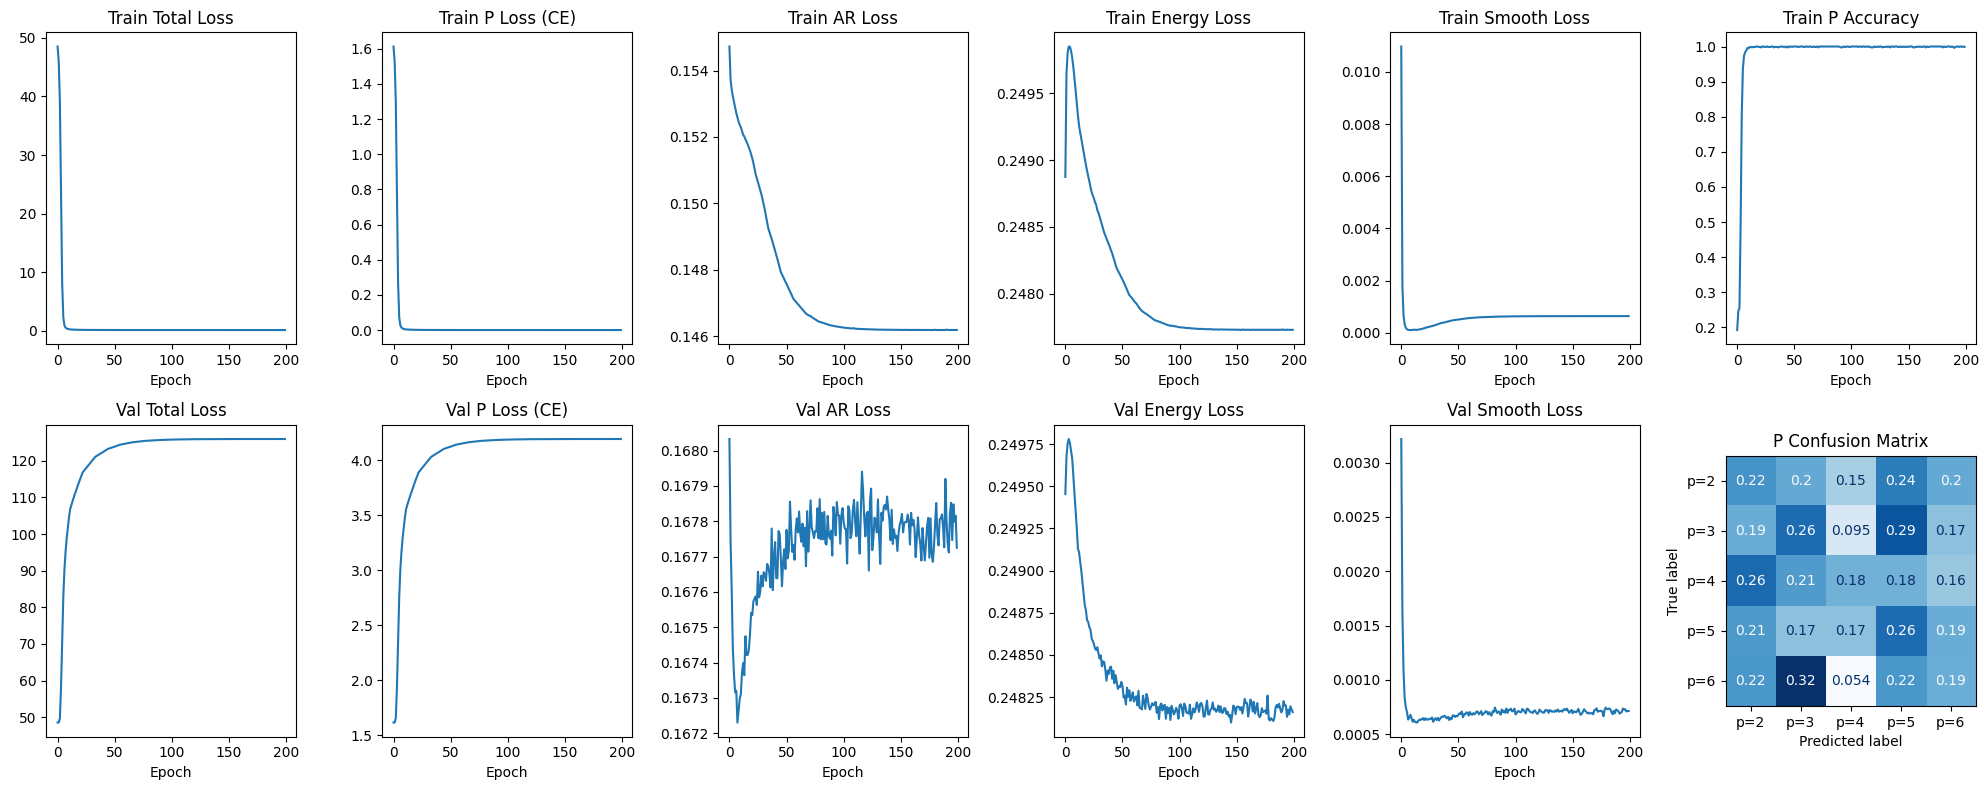

coeff_mse: 0.02703271433711052
signal_mse: 0.16356965899467468
p_mae: 1.56
p_mape: 0.47108333333333335
p2_acc: 0.21951219512195122
p3_acc: 0.23809523809523808
p4_acc: 0.21052631578947367
p5_acc: 0.2857142857142857
p6_acc: 0.16216216216216217
p_acc: 0.225


In [7]:
model, history, compute_metrics = do_bench_on_config(ablation_config["full"])

print("\n=== Compute Metrics (Table 4 style) ===")
for k, v in compute_metrics.items():
    print(f"{k}: {v}")

plot_history(history, model=model, val_loader=val_loader, device=device)
# Slice coef_val to match model output dimension (max_ar_order=6)
full_bench_results = bench_loop(model, X_val, coef_val[:, :, :6], p_val, device)
for k, v in full_bench_results.items():
    print(f"{k}: {v}")

In [8]:
import pandas as pd

# Combine benchmark results with compute metrics
all_metrics = {**full_bench_results, **compute_metrics}

ablation_df = pd.DataFrame({
    'full': all_metrics,
}).T

ablation_df

,coeff_mse,signal_mse,p_mae,p_mape,p2_acc,p3_acc,p4_acc,p5_acc,p6_acc,p_acc,Trainable Parameters,Sec / Step,Training Stability
full,0.027033,0.16357,1.56,0.471083,0.219512,0.238095,0.210526,0.285714,0.162162,0.225,652565,0.001,Stable


In [9]:
# Scalability probe with respect to hidden_dim (ICML Table style)
from scipy import stats

def get_model_size_mb(model):
    """Get model size in MB."""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)

def get_peak_memory_mb(device):
    """Get peak GPU memory in MB."""
    if device.type == 'cuda':
        return torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    return 0

scalability_results = []
batch_size = 32
seq_len = 600
n_timing_steps = 200

for hidden_dim in [32, 64, 128, 256, 512]:
    # Reset peak memory stats
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
    
    model = DeepLagEmbed(seq_len=seq_len, n_classes=5, max_ar_order=6, hidden_dim=hidden_dim)
    model = model.to(device)
    
    params = count_trainable_params(model)
    model_size_mb = get_model_size_mb(model)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Warmup (5 steps)
    model.train()
    warmup_count = 0
    for x_batch, p_batch in train_loader:
        if warmup_count >= 5:
            break
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        coeffs, p_logits, p_hard, x_hat = model(x_batch)
        loss = p_logits.mean()
        loss.backward()
        optimizer.step()
        warmup_count += 1
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats(device)
    
    # Training time measurement (n_timing_steps steps)
    train_times = []
    step_count = 0
    model.train()
    while step_count < n_timing_steps:
        for x_batch, p_batch in train_loader:
            if step_count >= n_timing_steps:
                break
            x_batch = x_batch.to(device)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.perf_counter()
            
            optimizer.zero_grad()
            coeffs, p_logits, p_hard, x_hat = model(x_batch)
            loss = p_logits.mean()
            loss.backward()
            optimizer.step()
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            train_times.append((time.perf_counter() - start) * 1000)  # Convert to ms
            step_count += 1
    
    # Get peak memory during training
    train_peak_mem = get_peak_memory_mb(device)
    
    # Inference time measurement (n_timing_steps steps)
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)
    
    test_times = []
    step_count = 0
    model.eval()
    with torch.no_grad():
        while step_count < n_timing_steps:
            for x_batch, p_batch in train_loader:
                if step_count >= n_timing_steps:
                    break
                x_batch = x_batch.to(device)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start = time.perf_counter()
                
                coeffs, p_logits, p_hard, x_hat = model(x_batch)
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                test_times.append((time.perf_counter() - start) * 1000)  # Convert to ms
                step_count += 1
    
    # Get peak memory during inference
    infer_peak_mem = get_peak_memory_mb(device)
    
    # Calculate statistics
    train_mean = np.mean(train_times)
    train_sem = stats.sem(train_times)
    train_std = np.std(train_times)
    test_mean = np.mean(test_times)
    test_sem = stats.sem(test_times)
    test_std = np.std(test_times)
    
    # Throughput (samples/sec)
    train_throughput = batch_size / (train_mean / 1000)  # samples/sec
    infer_throughput = batch_size / (test_mean / 1000)   # samples/sec
    
    scalability_results.append({
        "Hidden Dim": hidden_dim,
        "Parameters": params,
        "Model Size (MB)": round(model_size_mb, 2),
        "Train Time (ms)": train_mean,
        "Train SEM": train_sem,
        "Train Std": train_std,
        "Inference Time (ms)": test_mean,
        "Inference SEM": test_sem,
        "Inference Std": test_std,
        "Train Peak Mem (MB)": round(train_peak_mem, 1),
        "Infer Peak Mem (MB)": round(infer_peak_mem, 1),
        "Train Throughput (samples/s)": round(train_throughput, 1),
        "Infer Throughput (samples/s)": round(infer_throughput, 1),
    })
    print(f"hidden_dim={hidden_dim}: {params:,} params | Train: {train_mean:.2f}±{train_sem:.2f} ms | Infer: {test_mean:.2f}±{test_sem:.2f} ms | Mem: {train_peak_mem:.1f} MB")

scale_df = pd.DataFrame(scalability_results)

# Compute relative speedup (relative to largest model)
baseline_train = scale_df["Train Time (ms)"].iloc[-1]
baseline_infer = scale_df["Inference Time (ms)"].iloc[-1]
scale_df["Train Speedup"] = baseline_train / scale_df["Train Time (ms)"]
scale_df["Infer Speedup"] = baseline_infer / scale_df["Inference Time (ms)"]

# Create ICML-style display table
display_df = pd.DataFrame({
    "Hidden Dim": scale_df["Hidden Dim"],
    "Params": scale_df["Parameters"].apply(lambda x: f"{x:,}"),
    "Size (MB)": scale_df["Model Size (MB)"],
    "Train (ms)": scale_df.apply(lambda r: f"{r['Train Time (ms)']:.2f} ± {r['Train SEM']:.2f}", axis=1),
    "Infer (ms)": scale_df.apply(lambda r: f"{r['Inference Time (ms)']:.2f} ± {r['Inference SEM']:.2f}", axis=1),
    "Train Mem (MB)": scale_df["Train Peak Mem (MB)"],
    "Infer Mem (MB)": scale_df["Infer Peak Mem (MB)"],
    "Train (samp/s)": scale_df["Train Throughput (samples/s)"],
    "Infer (samp/s)": scale_df["Infer Throughput (samples/s)"],
    "Speedup↑": scale_df["Train Speedup"].apply(lambda x: f"{x:.2f}×"),
})
display_df = display_df.set_index("Hidden Dim")

print("\n" + "="*100)
print(f"  Scalability Analysis | {n_timing_steps} steps | batch={batch_size} | seq_len={seq_len} | device={device}")
print("="*100)
display(display_df)

# Also create a LaTeX-friendly version
print("\n=== LaTeX Table ===")
latex_df = pd.DataFrame({
    "d": scale_df["Hidden Dim"],
    "Params": scale_df["Parameters"].apply(lambda x: f"{x/1000:.1f}K" if x < 1e6 else f"{x/1e6:.2f}M"),
    "Size": scale_df["Model Size (MB)"].apply(lambda x: f"{x:.2f}"),
    "Train (ms)": scale_df.apply(lambda r: f"${r['Train Time (ms)']:.2f} \\pm {r['Train SEM']:.2f}$", axis=1),
    "Infer (ms)": scale_df.apply(lambda r: f"${r['Inference Time (ms)']:.2f} \\pm {r['Inference SEM']:.2f}$", axis=1),
    "Mem (MB)": scale_df["Train Peak Mem (MB)"],
    "Thru (s/s)": scale_df["Infer Throughput (samples/s)"].apply(lambda x: f"{x:.0f}"),
})
print(latex_df.to_latex(index=False, escape=False))

hidden_dim=32: 159,701 params | Train: 0.80±0.01 ms | Infer: 0.30±0.00 ms | Mem: 21.1 MB
hidden_dim=64: 319,893 params | Train: 0.81±0.00 ms | Infer: 0.31±0.00 ms | Mem: 21.9 MB
hidden_dim=128: 652,565 params | Train: 0.83±0.01 ms | Infer: 0.30±0.00 ms | Mem: 23.6 MB
hidden_dim=256: 1,367,061 params | Train: 0.85±0.00 ms | Infer: 0.31±0.00 ms | Mem: 27.4 MB
hidden_dim=512: 2,992,661 params | Train: 0.85±0.00 ms | Infer: 0.32±0.00 ms | Mem: 40.0 MB

  Scalability Analysis | 200 steps | batch=32 | seq_len=600 | device=cuda:1


,Params,Size (MB),Train (ms),Infer (ms),Train Mem (MB),Infer Mem (MB),Train (samp/s),Infer (samp/s),Speedup↑
Hidden Dim,,,,,,,,,
32,"159,701",0.61,0.80 ± 0.01,0.30 ± 0.00,21.1,21.1,39884.9,105761.6,1.05×
64,"319,893",1.22,0.81 ± 0.00,0.31 ± 0.00,21.9,22.0,39267.5,102174.7,1.04×
128,"652,565",2.49,0.83 ± 0.01,0.30 ± 0.00,23.6,23.9,38690.3,104966.5,1.02×
256,"1,367,061",5.21,0.85 ± 0.00,0.31 ± 0.00,27.4,28.1,37467.3,104485.2,0.99×
512,"2,992,661",11.42,0.85 ± 0.00,0.32 ± 0.00,40.0,39.8,37862.6,101538.2,1.00×



=== LaTeX Table ===
\begin{tabular}{rllllrl}
\toprule
d & Params & Size & Train (ms) & Infer (ms) & Mem (MB) & Thru (s/s) \\
\midrule
32 & 159.7K & 0.61 & $0.80 \pm 0.01$ & $0.30 \pm 0.00$ & 21.100000 & 105762 \\
64 & 319.9K & 1.22 & $0.81 \pm 0.00$ & $0.31 \pm 0.00$ & 21.900000 & 102175 \\
128 & 652.6K & 2.49 & $0.83 \pm 0.01$ & $0.30 \pm 0.00$ & 23.600000 & 104966 \\
256 & 1.37M & 5.21 & $0.85 \pm 0.00$ & $0.31 \pm 0.00$ & 27.400000 & 104485 \\
512 & 2.99M & 11.42 & $0.85 \pm 0.00$ & $0.32 \pm 0.00$ & 40.000000 & 101538 \\
\bottomrule
\end{tabular}

